https://www.research.autodesk.com/publications/same-stats-different-graphs/



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("datasaurus.csv")
df.head()

,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dataset  1846 non-null   str    
 1   x        1846 non-null   float64
 2   y        1846 non-null   float64
dtypes: float64(2), str(1)
memory usage: 43.4 KB


In [5]:
dfDino = df[df["dataset"] == "dino"]
dfDino.describe()

,x,y
count,142.000000,142.000000
mean,54.263273,47.832253
std,16.765142,26.935403
min,22.307700,2.948700
25%,44.102600,25.288450
50%,53.333300,46.025600
75%,64.743600,68.525675
max,98.205100,99.487200


<Axes: xlabel='x', ylabel='y'>

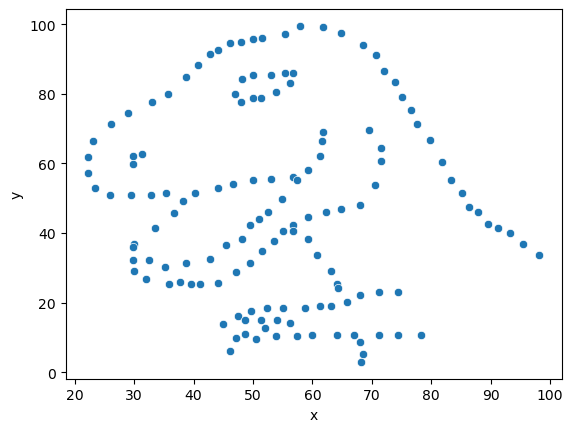

In [6]:
sns.scatterplot(x="x", y="y", data=dfDino)

In [7]:
df["dataset"].value_counts()

dataset
dino          142
away          142
h_lines       142
v_lines       142
x_shape       142
star          142
high_lines    142
dots          142
circle        142
bullseye      142
slant_up      142
slant_down    142
wide_lines    142
Name: count, dtype: int64

<Axes: xlabel='x', ylabel='y'>

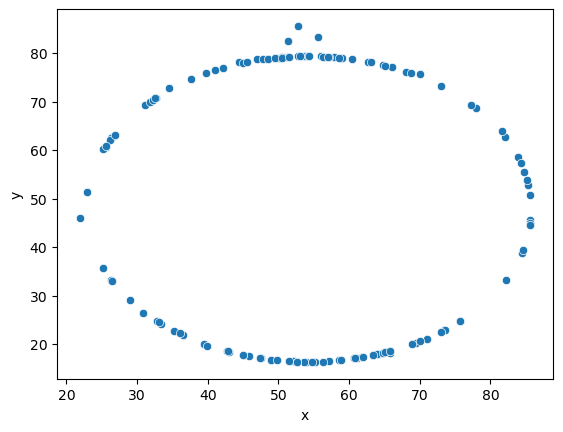

In [18]:
dfCircle = df[df["dataset"] == "circle"]
sns.scatterplot(x="x", y="y", data=dfCircle)

In [19]:
dfComparison = pd.DataFrame({
    "mean_x_dino": dfDino.groupby("dataset")["x"].mean(),
    "mean_y_dino": dfDino.groupby("dataset")["y"].mean(),
    "std_x_dino": dfDino.groupby("dataset")["x"].std(),
    "std_y_dino": dfDino.groupby("dataset")["y"].std(),
    "correlation_dino": dfDino.groupby("dataset").apply(lambda g: g["x"].corr(g["y"])),
    "mean_x_circle": dfCircle.groupby("dataset")["x"].mean(),
    "mean_y_circle": dfCircle.groupby("dataset")["y"].mean(),
    "std_x_circle": dfCircle.groupby("dataset")["x"].std(),
    "std_y_circle": dfCircle.groupby("dataset")["y"].std(),
    "correlation_circle": dfCircle.groupby("dataset").apply(lambda g: g["x"].corr(g["y"]))
})
dfComparison

,mean_x_dino,mean_y_dino,std_x_dino,std_y_dino,correlation_dino,mean_x_circle,mean_y_circle,std_x_circle,std_y_circle,correlation_circle
dataset,,,,,,,,,,
circle,NaN,NaN,NaN,NaN,NaN,54.26732,47.837717,16.760013,26.930036,-0.068343
dino,54.263273,47.832253,16.765142,26.935403,-0.064472,NaN,NaN,NaN,NaN,NaN
